# **CNN 모델링 실습**

* 패션 아이템 이미지 10가지 분류하기
    * 데이터 : 이미지(1, 32, 32) 6만장
    * 10가지 클래스로 분류하기 위한 모델 생성

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchsummary import summary

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    tr_loss = 0                  # 전체 데이터셋의 크기
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [33]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')


    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### (4) 데이터 셋

#### 1) 다운로드

In [8]:
train_dataset = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.1MB/s]


#### 2) 데이터셋 정보

* 데이터셋 일반 정보

In [9]:
train_dataset, test_dataset

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

* 데이터셋의 x와 y

In [10]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

* y(target)의 클래스

In [11]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

* 데이터 1건

In [12]:
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

* 데이터 이미지 확인

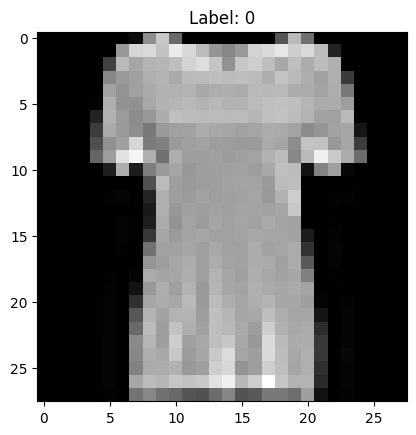

In [13]:
n = 10
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## **2.데이터 준비**

* 다운 받은 데이터셋은 다음의 전처리가 완료됨
    * x, y가 분리
    * train, test 분리
    * 스케일링

### (1) train은 데이터로더로 생성

In [14]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)

In [15]:
# 첫번째 배치만 로딩해서 살펴보기
for X, y in train_dataloader:
    print(f"Shape of X [batch, channels, height, width]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### (2) validation, test 준비
* 데이터셋 분할
    * validation : 학습시, 에포크마다 성능 검증용
    * test : 모델 생성 후 최종 검증용
* dataset의 data 속성으로 데이터를 뽑으면 원본데이터가 나옵니다.
    * 스케일링 안된 데이터
    * 5000, 28, 28 : 3차원 데이터셋
* 그래서 모델링에 사용하려면 두가지 전처리를 다시 해줘야 함
    * 스케일링 : 원본데이터가 0~255 까지 숫자이므로, 255로 나눠주면 됨
    * 4차원 변환 : 5000, 1, 28, 28

In [16]:
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [17]:
x_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

#### 1) 스케일링

In [18]:
x_val = x_val / 255
x_test = x_test/ 255

#### 2) 3차원 데이터셋 --> 4차원 데이터셋

In [19]:
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)

print(x_val.shape, x_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## **3.모델링**

### (1) 모델 선언

In [21]:
n_class = 10

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(64*7*7, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, n_class)
).to(device)

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

### (2) 학습

In [26]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for i in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn ,device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {i+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/10 | Train Loss: 0.4901 | Val Loss: 0.3703
Epoch 2/10 | Train Loss: 0.3127 | Val Loss: 0.3410
Epoch 3/10 | Train Loss: 0.2652 | Val Loss: 0.3020
Epoch 4/10 | Train Loss: 0.2334 | Val Loss: 0.2739
Epoch 5/10 | Train Loss: 0.2096 | Val Loss: 0.2811
Epoch 6/10 | Train Loss: 0.1890 | Val Loss: 0.2733
Epoch 7/10 | Train Loss: 0.1706 | Val Loss: 0.2698
Epoch 8/10 | Train Loss: 0.1530 | Val Loss: 0.2887
Epoch 9/10 | Train Loss: 0.1388 | Val Loss: 0.2862
Epoch 10/10 | Train Loss: 0.1245 | Val Loss: 0.3116


### (3) 모델 평가

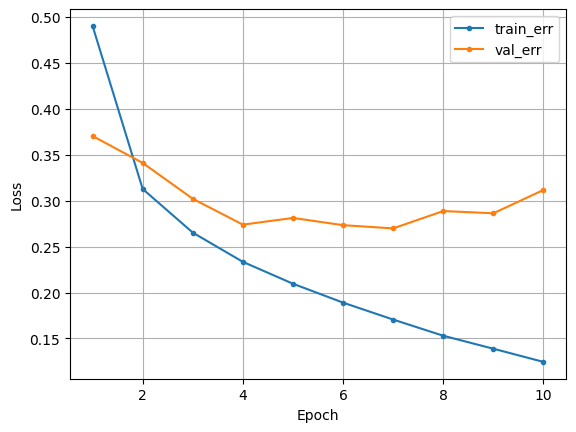

In [35]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [36]:
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred[:5]

tensor([[ -1.0888, -17.2195,   7.6754, -12.1066,  -4.1138, -13.9066,   1.3867,
         -17.0728,  -5.3830, -16.4975],
        [  4.0810, -15.0237, -15.5804,  17.1724, -13.3226, -26.6068,  -7.5727,
         -28.9472, -12.1794, -30.5000],
        [  0.9984,  -8.2361,  -8.8522,  -3.2522,  -2.4865, -16.5358,   4.6037,
         -17.9216,  -3.1584, -16.6407],
        [ -4.9782, -10.5685,   2.0302, -12.7403,   8.2692, -15.8756,  -2.2644,
         -15.2700, -10.3169, -14.8470],
        [ -5.7398, -11.1680,  -4.0731,  -3.0575,   3.4945, -10.0389,   4.4130,
          -8.5839,  -8.3167, -11.7535]], device='cuda:0')

In [37]:
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

In [38]:
cm = confusion_matrix(y_test.numpy(), pred)
cm

array([[465,   0,   2,   4,   1,   0,  20,   0,   1,   0],
       [  3, 508,   1,   5,   0,   0,   1,   0,   1,   0],
       [ 19,   0, 412,   1,  20,   0,  27,   0,   0,   0],
       [ 13,   0,   1, 477,   5,   0,   4,   0,   0,   0],
       [  1,   0,  20,  12, 424,   0,  21,   0,   1,   0],
       [  0,   0,   0,   0,   0, 504,   0,   8,   0,   3],
       [101,   0,  14,  21,  24,   0, 356,   0,   2,   0],
       [  0,   0,   0,   0,   0,   4,   0, 490,   0,   6],
       [  2,   0,   0,   1,   0,   0,   1,   2, 468,   0],
       [  0,   0,   0,   0,   0,   2,   1,  11,   0, 509]])

In [39]:
print(accuracy_score(y_test.numpy(), pred))
print('-'*100)
print(classification_report(y_test.numpy(), pred))

0.9226
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.94      0.85       493
           1       1.00      0.98      0.99       519
           2       0.92      0.86      0.89       479
           3       0.92      0.95      0.93       500
           4       0.89      0.89      0.89       479
           5       0.99      0.98      0.98       515
           6       0.83      0.69      0.75       518
           7       0.96      0.98      0.97       500
           8       0.99      0.99      0.99       474
           9       0.98      0.97      0.98       523

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000

